In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
df = pd.read_csv('../data/features.csv')
df.head()

,date,home_team,away_team,home_GF5,home_GA5,home_W5,home_D5,home_L5,home_points5,home_mean_competition5,home_matches_used5,away_GF5,away_GA5,away_W5,away_D5,away_L5,away_points5,away_mean_competition5,away_matches_used5,home_GF10,home_GA10,home_points10,home_mean_competition10,home_matches_used10,away_GF10,away_GA10,away_points10,away_mean_competition10,away_matches_used10,home_elo,away_elo,elo_diff,home_win_streak,away_win_streak,home_unbeaten_streak,away_unbeaten_streak,h2h_home_wins,h2h_away_wins,h2h_draws,h2h_matches,neutral,competition_level,home_score,away_score
0,2000-01-04,Egypt,Togo,0.0,0.0,0,0,0,0,0.0,0,0.0,0.0,0,0,0,0,0.0,0,0.0,0.0,0,0.0,0,0.0,0.0,0,0.0,0,1500.0,1500.0,0.0,0,0,0,0,0,0,0,0,0,1,2.0,1.0
1,2000-01-07,Tunisia,Togo,0.0,0.0,0,0,0,0,0.0,0,1.0,2.0,0,0,1,0,1.0,1,0.0,0.0,0,0.0,0,1.0,2.0,0,1.0,1,1500.0,1495.0,5.0,0,0,0,0,0,0,0,0,0,1,7.0,0.0
2,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,0,0,0,0,0.0,0,0.0,0.0,0,0,0,0,0.0,0,0.0,0.0,0,0.0,0,0.0,0.0,0,0.0,0,1500.0,1500.0,0.0,0,0,0,0,0,0,0,0,0,1,0.0,0.0
3,2000-01-09,Mexico,Iran,0.0,0.0,0,0,0,0,0.0,0,0.0,0.0,0,0,0,0,0.0,0,0.0,0.0,0,0.0,0,0.0,0.0,0,0.0,0,1500.0,1500.0,0.0,0,0,0,0,0,0,0,0,1,1,2.0,1.0
4,2000-01-09,Ivory Coast,Egypt,0.0,0.0,0,0,0,0,0.0,0,2.0,1.0,1,0,0,3,1.0,1,0.0,0.0,0,0.0,0,2.0,1.0,3,1.0,1,1500.0,1505.0,-5.0,0,1,0,1,0,0,0,0,0,1,2.0,0.0


In [4]:
df.tail()

,date,home_team,away_team,home_GF5,home_GA5,home_W5,home_D5,home_L5,home_points5,home_mean_competition5,home_matches_used5,away_GF5,away_GA5,away_W5,away_D5,away_L5,away_points5,away_mean_competition5,away_matches_used5,home_GF10,home_GA10,home_points10,home_mean_competition10,home_matches_used10,away_GF10,away_GA10,away_points10,away_mean_competition10,away_matches_used10,home_elo,away_elo,elo_diff,home_win_streak,away_win_streak,home_unbeaten_streak,away_unbeaten_streak,h2h_home_wins,h2h_away_wins,h2h_draws,h2h_matches,neutral,competition_level,home_score,away_score
25362,2026-06-16,Austria,Jordan,2.0,0.4,4,1,0,13,1.8,5,1.4,2.6,0,2,3,2,1.2,5,2.7,0.4,25,2.4,10,1.7,1.5,17,1.6,10,1695.207760,1669.269913,25.937847,3,0,5,0,0,0,0,0,1,6,3.0,1.0
25363,2026-06-17,Uzbekistan,Colombia,1.2,1.4,1,2,2,5,1.4,5,2.0,1.2,3,0,2,9,1.0,5,1.4,0.9,15,1.6,10,2.5,1.0,22,1.4,10,1722.272638,1824.508433,-102.235795,0,2,0,2,0,0,0,0,1,6,1.0,3.0
25364,2026-06-17,England,Croatia,1.4,0.4,3,1,1,10,1.4,5,1.6,1.8,3,0,2,9,1.4,5,2.4,0.2,25,2.0,10,1.9,1.0,22,2.2,10,1859.004852,1785.250508,73.754344,2,1,2,1,6,3,1,10,1,6,4.0,2.0
25365,2026-06-17,Portugal,DR Congo,3.0,0.6,4,1,0,13,1.4,5,0.8,0.6,2,1,2,7,2.2,5,2.6,0.9,23,2.2,10,1.1,0.5,18,3.2,10,1843.412382,1640.242529,203.169853,3,0,5,0,0,0,0,0,1,6,1.0,1.0
25366,2026-06-17,Ghana,Panama,0.6,2.2,0,1,4,1,1.0,5,2.0,2.2,2,2,1,8,1.0,5,1.1,1.4,11,1.9,10,1.8,1.6,16,1.6,10,1570.703927,1720.609500,-149.905573,0,0,1,2,0,0,0,0,1,6,1.0,0.0


In [5]:
df.shape

(25367, 44)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25367 entries, 0 to 25366
Data columns (total 44 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     25367 non-null  str    
 1   home_team                25367 non-null  str    
 2   away_team                25367 non-null  str    
 3   home_GF5                 25367 non-null  float64
 4   home_GA5                 25367 non-null  float64
 5   home_W5                  25367 non-null  int64  
 6   home_D5                  25367 non-null  int64  
 7   home_L5                  25367 non-null  int64  
 8   home_points5             25367 non-null  int64  
 9   home_mean_competition5   25367 non-null  float64
 10  home_matches_used5       25367 non-null  int64  
 11  away_GF5                 25367 non-null  float64
 12  away_GA5                 25367 non-null  float64
 13  away_W5                  25367 non-null  int64  
 14  away_D5                  25367 no

In [7]:
df["date"] = pd.to_datetime(df["date"])

In [8]:
df["home_score"] = df["home_score"].astype(int)
df["away_score"] = df["away_score"].astype(int)

In [9]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,25367,2013-04-29 14:32:09.782788,2000-01-04 00:00:00,2006-10-11 00:00:00,2013-03-02 00:00:00,2019-10-13 00:00:00,2026-06-17 00:00:00,NaN
home_GF5,25367.0,1.391005,0.0,0.8,1.2,1.8,13.6,0.862356
home_GA5,25367.0,1.340078,0.0,0.8,1.2,1.75,19.0,0.939625
home_W5,25367.0,1.92096,0.0,1.0,2.0,3.0,5.0,1.265081
home_D5,25367.0,1.143178,0.0,0.0,1.0,2.0,5.0,0.965991
home_L5,25367.0,1.846533,0.0,1.0,2.0,3.0,5.0,1.302651
home_points5,25367.0,6.906059,0.0,4.0,7.0,10.0,15.0,3.62006
home_mean_competition5,25367.0,2.401637,0.0,1.8,2.2,3.0,6.0,0.879586
home_matches_used5,25367.0,4.910671,0.0,5.0,5.0,5.0,5.0,0.569521
away_GF5,25367.0,1.348922,0.0,0.8,1.2,1.8,21.0,0.846369


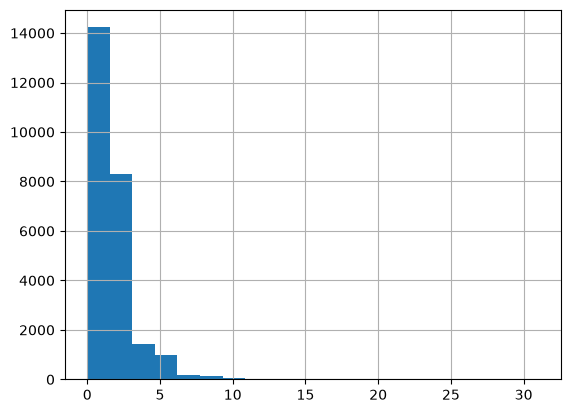

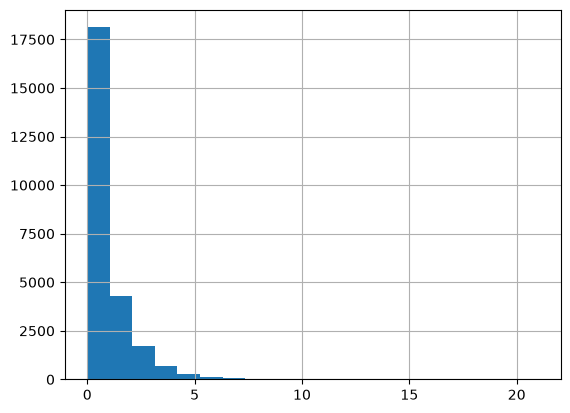

In [10]:
df["home_score"].hist(bins=20)
plt.show()

df["away_score"].hist(bins=20)
plt.show()

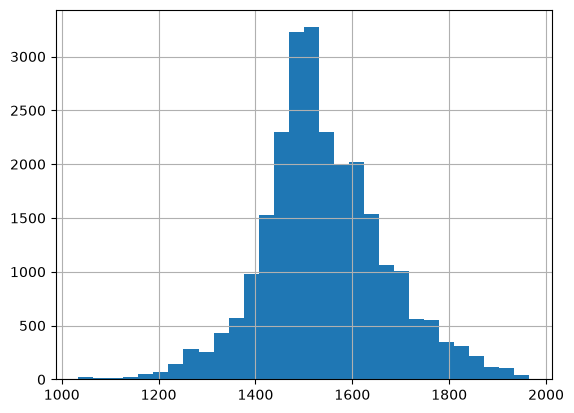

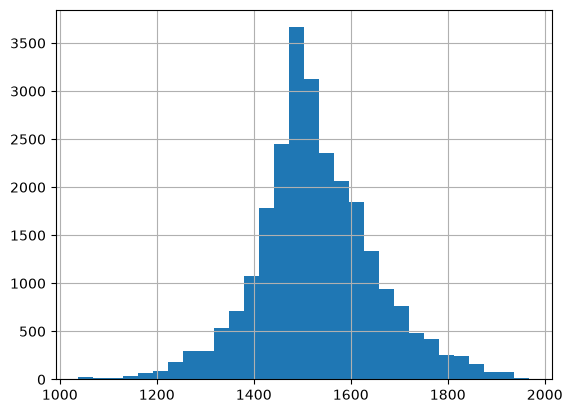

In [11]:
df["home_elo"].hist(bins=30)
plt.show()

df["away_elo"].hist(bins=30)
plt.show()

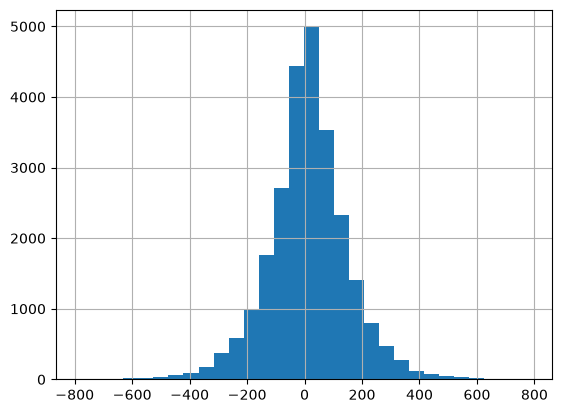

In [12]:
df["elo_diff"].hist(bins=30)
plt.show()

In [13]:
corr = df.corr(numeric_only=True)

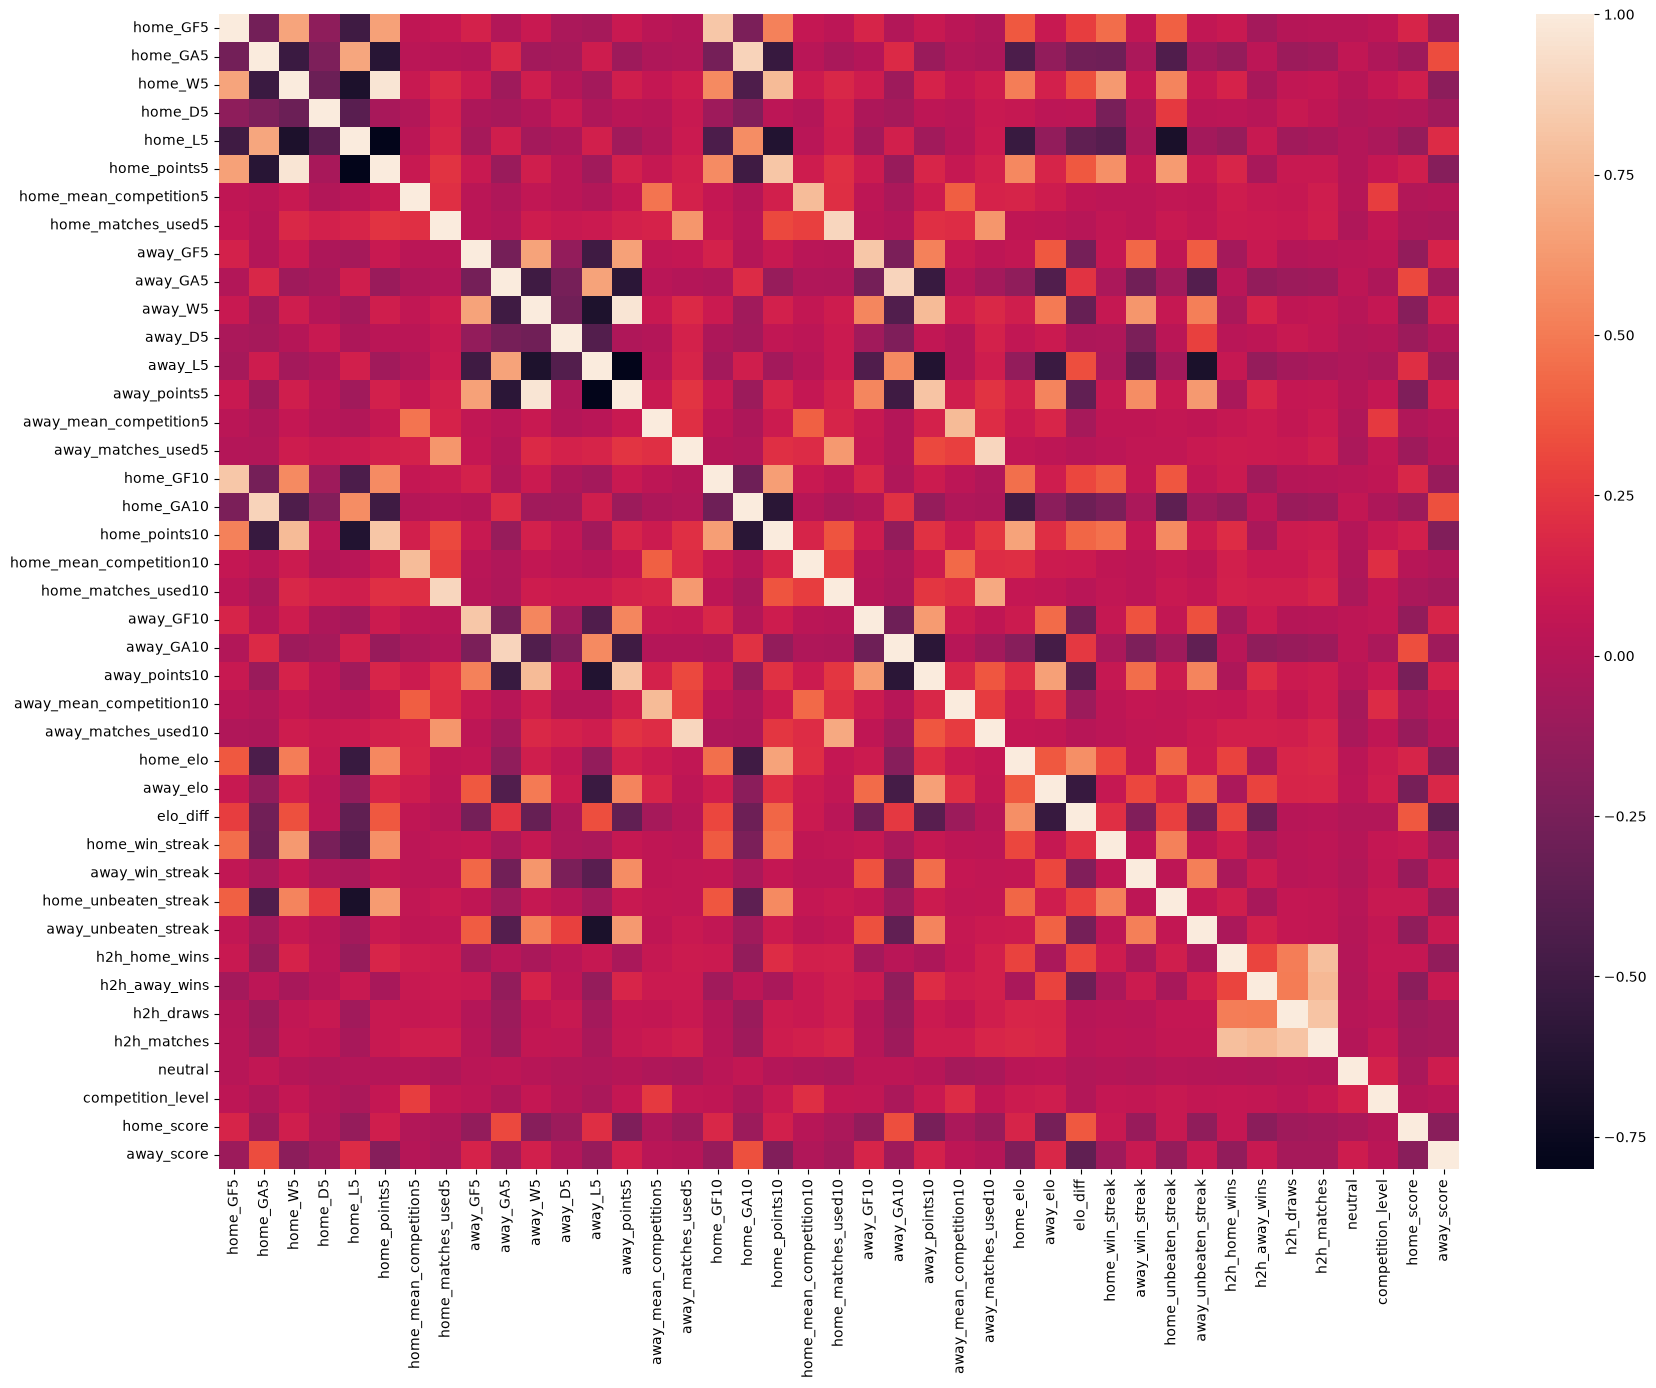

In [14]:
import seaborn as sns

plt.figure(figsize=(20,15))
sns.heatmap(corr)
plt.show()

In [15]:
corr["home_score"].sort_values()

away_elo                  -0.253974
away_points10             -0.250694
away_points5              -0.222614
away_W5                   -0.187389
away_score                -0.179503
h2h_away_wins             -0.171022
away_unbeaten_streak      -0.148890
away_GF10                 -0.144451
away_GF5                  -0.134479
home_L5                   -0.125445
away_win_streak           -0.112657
away_matches_used10       -0.112017
away_D5                   -0.100135
home_GA10                 -0.097765
home_GA5                  -0.096958
away_matches_used5        -0.091239
h2h_draws                 -0.089376
h2h_matches               -0.074091
neutral                   -0.046931
home_matches_used10       -0.035085
away_mean_competition10   -0.034380
home_matches_used5        -0.030249
away_mean_competition5    -0.018409
home_mean_competition5    -0.012278
home_D5                   -0.008648
competition_level          0.006455
home_mean_competition10    0.014107
h2h_home_wins              0

In [16]:
corr["away_score"].sort_values()

elo_diff                  -0.351507
home_elo                  -0.217625
home_points10             -0.215930
home_points5              -0.190031
home_score                -0.179503
home_W5                   -0.160828
h2h_home_wins             -0.146162
home_unbeaten_streak      -0.127788
away_L5                   -0.116023
home_GF10                 -0.115601
home_GF5                  -0.102604
away_GA10                 -0.089878
home_win_streak           -0.088344
away_GA5                  -0.083125
home_D5                   -0.080272
home_matches_used10       -0.067768
h2h_draws                 -0.061813
h2h_matches               -0.055236
home_matches_used5        -0.044138
home_mean_competition10   -0.015649
away_D5                   -0.008901
away_matches_used10        0.002704
home_mean_competition5     0.003516
away_matches_used5         0.005162
away_mean_competition5     0.016395
competition_level          0.022652
away_mean_competition10    0.036807
h2h_away_wins              0

In [18]:
df.to_csv('../data/features_processed.csv', index=False)